# Multi-objective BO: Perovskite hysteresis JV fits with SIMsalabim (fake data)
This notebook is a demonstration of how to fit scan-speed dependent JV curves with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.

In [1]:
# Import necessary libraries
import warnings, os, sys, shutil
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import torch, copy, uuid
import pySIMsalabim as sim
from pySIMsalabim.experiments.hysteresis import *
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks
import joblib  # Import joblib for parallel processing

try:
    from optimpv import *
    from optimpv.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.axBOtorch.axUtils import *

[INFO 08-13 18:16:45] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 08-13 18:16:45] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Define the parameters for the simulation

In [2]:
params = [] # list of parameters to be optimized

mun = FitParam(name = 'l2.mu_n', value = 6e-4, bounds = [1e-5,1e-3], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 4e-4, bounds = [1e-5,1e-3], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_p$', unit=r'm$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1e20, bounds = [1e19,1e21], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T}$', unit=r'm$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(bulk_tr)

HTL_int_trap = FitParam(name = 'l1.N_t_int', value = 5e11, bounds = [1e11,1e13], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T,int}^{HTL}$', unit='m$^{-2}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(HTL_int_trap)

ETL_int_trap = FitParam(name = 'l2.N_t_int', value = 4e12, bounds = [1e11,1e13], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T,int}^{ETL}$', unit='m$^{-2}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(ETL_int_trap)

Nions = FitParam(name = 'l2.N_ions', value = 1e22, bounds = [1e20,1e22], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$C_{ions}$', unit='m$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(Nions)

muions = FitParam(name = 'l2.mu_ions', value = 5.7e-12, bounds = [1e-13,1e-11], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = True, stepsize = None, display_name=r'$\mu_{ions}$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(muions)

R_series = FitParam(name = 'R_series', value = 0e-4, bounds = [0e-5,1e-3], type='fixed', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(R_series) # here we switch of the Rseries and set it to 0 as it having a series resistance dramatically slows down the simulation. We can switch it on later if needed.

num_free_params = 0
for p in params:
    if p.type != 'fixed'    :
        num_free_params += 1
# save the original parameters for later
params_orig = copy.deepcopy(params)

## Generate some fake data
Here we generate some fake data to fit. The data is generated using the same model as the one used for the fitting, so it is a good test of the fitting procedure. For more information on how to run SIMsalabim from python see the [pySIMsalabim](https://github.com/kostergroup/pySIMsalabim) package.

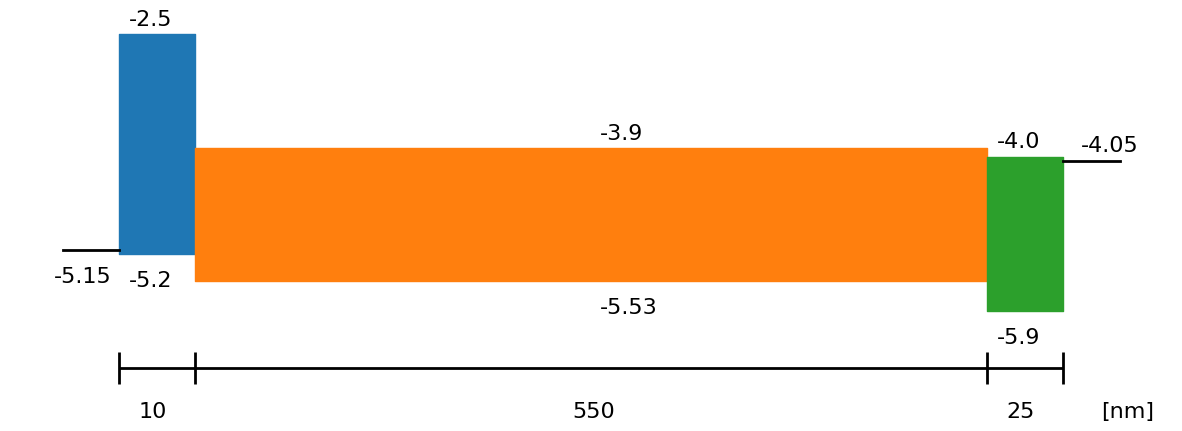

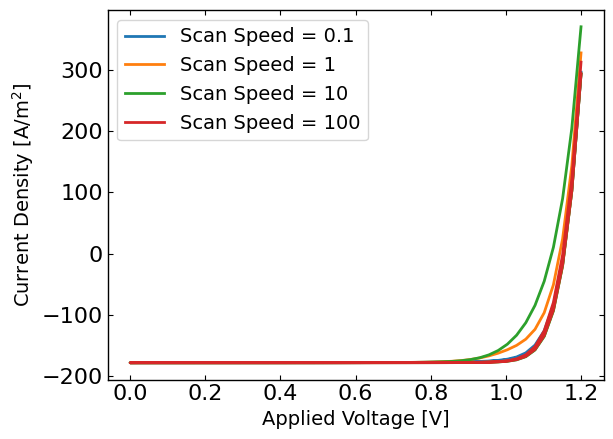

In [3]:
# First we do the JV simulation with the original parameters
# Set the session path for the simulation and the input files
session_path_zimt = os.path.join(os.path.join(os.path.abspath('../'),'SIMsalabim','ZimT'))
input_path_zimt = os.path.join(os.path.join(os.path.join(os.path.abspath('../'),'Data','simsalabim_test_inputs','fakePerovskite')))
simulation_setup_filename_zimt = 'simulation_setup_zimt_fakePerovskite.txt'
simulation_setup_zimt = os.path.join(session_path_zimt, simulation_setup_filename_zimt)
optical_files = ['nk_glass.txt','nk_ITO.txt','nk_PTAA.txt','nk_FACsPbIBr.txt','nk_C60_1.txt','nk_Au.txt']
# path to the layer files defined in the simulation_setup file
l1 = 'PTAA.txt'
l2 = 'fakePerovskite.txt'
l3 = 'C60.txt'
l1 = os.path.join(input_path_zimt, l1)
l2 = os.path.join(input_path_zimt, l2)
l3 = os.path.join(input_path_zimt, l3)

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path_zimt):
    os.makedirs(session_path_zimt)
for file in [l1,l2,l3,simulation_setup_filename_zimt]:
    file = os.path.join(input_path_zimt, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path_zimt, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path_zimt, os.path.basename(file)))
    else:
        print('File already exists: ',file)
# copy the optical files to the session path
for file in optical_files:
    file = os.path.join(input_path_zimt, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path_zimt, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path_zimt, os.path.basename(file)))

# Show the device structure
fig = sim.plot_band_diagram(simulation_setup_zimt, session_path_zimt)

# Set the JV parameters
direction = -1
G_frac = 1
Vmin = 0
Vmax = 1.2
steps = 100

cmd_pars = [] # see pySIMsalabim documentation for the command line parameters
# Add the parameters to the command line arguments
for param in params:
    if param.name == 'l2.N_ions':
        cmd_pars.append({'par':'l2.N_cation', 'val':str(param.value)})
        cmd_pars.append({'par':'l2.N_anion', 'val':str(param.value)})
    elif param.name == 'l2.mu_ions':
        cmd_pars.append({'par':'l2.mu_cation', 'val':str(param.value)})
        cmd_pars.append({'par':'l2.mu_anion', 'val':str(param.value)})
    else:
        cmd_pars.append({'par':param.name, 'val':str(param.value)})

# cmd_pars.append({'par':'tolVint', 'val':str(1e-5)}) # add the series resistance
# Define a function to run a single hysteresis simulation
def run_hysteresis_simulation(scan_speed, session_path, simulation_setup, direction, G_frac, Vmin, Vmax, steps, cmd_pars):
    UUID = str(uuid.uuid4())
    ret, mess, rms = Hysteresis_JV(simulation_setup, session_path, 0, scan_speed, direction, G_frac, 
                                 Vmin=Vmin, Vmax=Vmax, steps=steps, UUID=UUID, cmd_pars=cmd_pars)
    
    # Load the data
    data = pd.read_csv(os.path.join(session_path, 'tj_'+UUID+'.dat'), sep=r'\s+')
    
    # Extract the data
    X = np.asarray(data['Vext'].values)
    y = np.asarray(data['Jext'].values)
    
    return scan_speed, X, y, UUID

# List of scan speeds to simulate
scan_speeds = [0.1, 1, 10, 100]

# Run simulations in parallel
results = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(run_hysteresis_simulation)(
        scan_speed, session_path_zimt, simulation_setup_zimt, direction, 
        G_frac, Vmin, Vmax, steps, cmd_pars
    ) for scan_speed in scan_speeds
)

# Extract results
X_data = {}
y_data = {}
UUIDs = {}

for scan_speed, X, y, UUID in results:
    X_data[scan_speed] = X
    y_data[scan_speed] = y
    UUIDs[scan_speed] = UUID

# Assign to variables for backward compatibility
X1, y1 = X_data[0.1], y_data[0.1]
X2, y2 = X_data[1], y_data[1]
X3, y3 = X_data[10], y_data[10]
X4, y4 = X_data[100], y_data[100]

# Plot the results
plt.figure()

plt.plot(X1, y1, label=f'Scan Speed = 0.1')
plt.plot(X2, y2, label=f'Scan Speed = 1')
plt.plot(X3, y3, label=f'Scan Speed = 10')
plt.plot(X4, y4, label=f'Scan Speed = 100')

plt.xlabel('Applied Voltage [V]')
plt.ylabel('Current Density [A/m$^2$]')
plt.legend()
plt.show()




## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.DDfits.HysteresisAgent import HysteresisAgent

metric = 'nrmse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'
threshold = 0.1 # need this to get a reference point for the hypervolume calculation

hyst1 = HysteresisAgent(params, X1, y1, session_path_zimt, Vmin, Vmax, scan_speeds[0], steps, direction, G_frac=1, simulation_setup=simulation_setup_zimt, metric=[metric], loss=[loss], threshold= [threshold],minimize=[True], name='Hyst1')

hyst2 = HysteresisAgent(params, X2, y2, session_path_zimt, Vmin, Vmax, scan_speeds[1], steps, direction, G_frac=1, simulation_setup=simulation_setup_zimt, metric=[metric], loss=[loss], threshold= [threshold],minimize=[True], name='Hyst2')

hyst3 = HysteresisAgent(params, X3, y3, session_path_zimt, Vmin, Vmax, scan_speeds[2], steps, direction, G_frac=1, simulation_setup=simulation_setup_zimt, metric=[metric], loss=[loss], threshold= [threshold],minimize=[True], name='Hyst3')

hyst4 = HysteresisAgent(params, X4, y4, session_path_zimt, Vmin, Vmax, scan_speeds[3], steps, direction, G_frac=1, simulation_setup=simulation_setup_zimt, metric=[metric], loss=[loss], threshold= [threshold],minimize=[True], name='Hyst4')


In [5]:
from optimpv.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
from botorch.acquisition.multi_objective.logei import qLogExpectedHypervolumeImprovement     
from ax.adapter.transforms.standardize_y import StandardizeY
from ax.adapter.transforms.unit_x import UnitX
from ax.adapter.transforms.remove_fixed import RemoveFixed
from ax.adapter.transforms.log import Log
from ax.generators.torch.botorch_modular.utils import ModelConfig
from ax.generators.torch.botorch_modular.surrogate import SurrogateSpec
from gpytorch.kernels import MaternKernel
from gpytorch.kernels import ScaleKernel
from botorch.models import SingleTaskGP

model_gen_kwargs_list = None
parameter_constraints = None

model_kwargs_list = [{},{},{"torch_device":torch.device("cuda" if torch.cuda.is_available() else "cpu"),'botorch_acqf_class':qLogExpectedHypervolumeImprovement,'transforms':[RemoveFixed, Log,UnitX, StandardizeY],'surrogate_spec':SurrogateSpec(model_configs=[ModelConfig(botorch_model_class=SingleTaskGP,covar_module_class=ScaleKernel, covar_module_options={'base_kernel':MaternKernel(nu=2.5, ard_num_dims=num_free_params)})])}]

optimizer = axBOtorchOptimizer(params = params, agents = [hyst1, hyst2, hyst3, hyst4], models = ['CENTER','SOBOL','BOTORCH_MODULAR'],n_batches = [1,1,20], batch_size = [1,10,2], ax_client = None,  max_parallelism = -1, model_kwargs_list = model_kwargs_list, model_gen_kwargs_list = None, name = 'ax_opti')


In [6]:
optimizer.optimize() # run the optimization with ax

[INFO 08-13 18:17:02] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'l2.mu_n': -4.0, 'l2.mu_p': -4.0, 'l2.N_t_bulk': 1e+20, 'l1.N_t_int': 1000000000000.0, 'l2.N_t_int': 1000000000000.0, 'l2.N_ions': 1e+21, 'l2.mu_ions': -12.0}
[INFO 08-13 18:17:16] optimpv.axBOtorchOptimizer: Trial 0 completed with results: {'Hyst1_JV_nrmse_linear': np.float64(0.08498926875954489), 'Hyst2_JV_nrmse_linear': np.float64(0.07765588194941991), 'Hyst3_JV_nrmse_linear': np.float64(0.0696485492867804), 'Hyst4_JV_nrmse_linear': np.float64(0.08292429135537334)} and parameters: {'l2.mu_n': -4.0, 'l2.mu_p': -4.0, 'l2.N_t_bulk': 1e+20, 'l1.N_t_int': 1000000000000.0, 'l2.N_t_int': 1000000000000.0, 'l2.N_ions': 1e+21, 'l2.mu_ions': -12.0}
[INFO 08-13 18:17:16] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'l2.mu_n': -4.093041753396392, 'l2.mu_p': -4.4247758481651545, 'l2.N_t_bulk': 1.2108783402449297e+19, 'l1.N_t_int': 1060817213971.2566, 'l2.N_t_int': 111190344500.15097, 'l2.N_ions': 1.88917044238365

In [7]:
# get the best parameters and update the params list in the optimizer and the agent
ax_client = optimizer.ax_client # get the ax client
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
hyst1.params = optimizer.params # update the params list in the agent with the best parameters
hyst2.params = optimizer.params # update the params list in the agent with the best parameters
hyst3.params = optimizer.params # update the params list in the agent with the best parameters
hyst4.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p,po in zip(optimizer.params, params_orig):
    print(p.name, 'fitted value:', p.value, 'original value:', po.value)
    
print('\nSimSS command line:')
print(hyst1.get_SIMsalabim_clean_cmd(hyst1.params,sim_type='zimt')) # print the simss command line with the best parameters


Best parameters:
l2.mu_n fitted value: 0.00013319280656484567 original value: 0.0006
l2.mu_p fitted value: 0.001 original value: 0.0004
l2.N_t_bulk fitted value: 2.6332102750240306e+20 original value: 1e+20
l1.N_t_int fitted value: 523132494247.9424 original value: 500000000000.0
l2.N_t_int fitted value: 2150641864459.8833 original value: 4000000000000.0
l2.N_ions fitted value: 1e+22 original value: 1e+22
l2.mu_ions fitted value: 5.828891189322099e-12 original value: 5.7e-12
R_series fitted value: 0.0 original value: 0.0

SimSS command line:
./zimt -l2.mu_n 0.00013319280656484567 -l2.mu_p 0.001 -l2.N_t_bulk 2.6332102750240306e+20 -l1.N_t_int 523132494247.9424 -l2.N_t_int 2150641864459.8833 -l2.N_anion 1e+22 -l2.N_cation 1e+22 -l2.mu_anion 5.828891189322099e-12 -l2.mu_cation 5.828891189322099e-12 -R_series 0.0


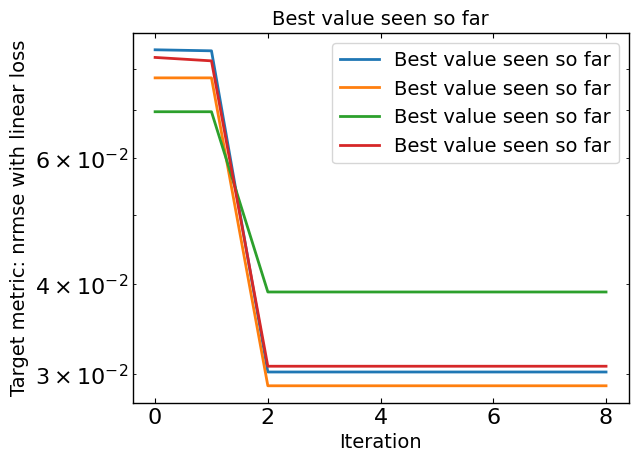

In [8]:
# Plot optimization results
data = ax_client.summarize()
all_metrics = optimizer.all_metrics
plt.figure()
plt.plot(np.minimum.accumulate(data[all_metrics]), label="Best value seen so far")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target metric: " + metric + " with " + loss + " loss")
plt.legend()
plt.title("Best value seen so far")

plt.show()

Pareto frontier: [({'l2.mu_n': -3.8755192297719776, 'l2.mu_p': -3.0, 'l2.N_t_bulk': 2.6332102750240306e+20, 'l1.N_t_int': 523132494247.9424, 'l2.N_t_int': 2150641864459.8833, 'l2.N_ions': 1e+22, 'l2.mu_ions': -11.234414051786072}, {'Hyst1_JV_nrmse_linear': (np.float64(0.0027907833420766997), nan), 'Hyst2_JV_nrmse_linear': (np.float64(0.00660904181228305), nan), 'Hyst3_JV_nrmse_linear': (np.float64(0.025560525178246266), nan), 'Hyst4_JV_nrmse_linear': (np.float64(0.0031804365901938764), nan)}, 48, '48_0'), ({'l2.mu_n': -3.7768253712767628, 'l2.mu_p': -3.0, 'l2.N_t_bulk': 2.2602618640751198e+20, 'l1.N_t_int': 503072480536.1889, 'l2.N_t_int': 2853244521379.9077, 'l2.N_ions': 1e+22, 'l2.mu_ions': -11.221121713344468}, {'Hyst1_JV_nrmse_linear': (np.float64(0.004445484766950791), nan), 'Hyst2_JV_nrmse_linear': (np.float64(0.008168483173615593), nan), 'Hyst3_JV_nrmse_linear': (np.float64(0.022716063463621084), nan), 'Hyst4_JV_nrmse_linear': (np.float64(0.004733419067706095), nan)}, 44, '44_0'

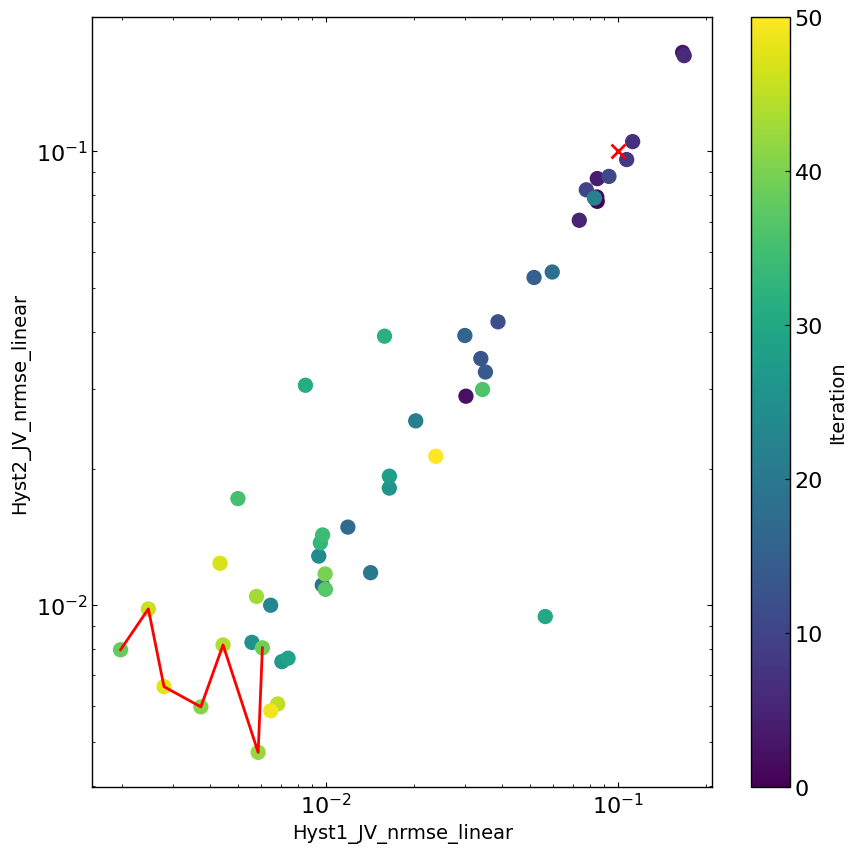

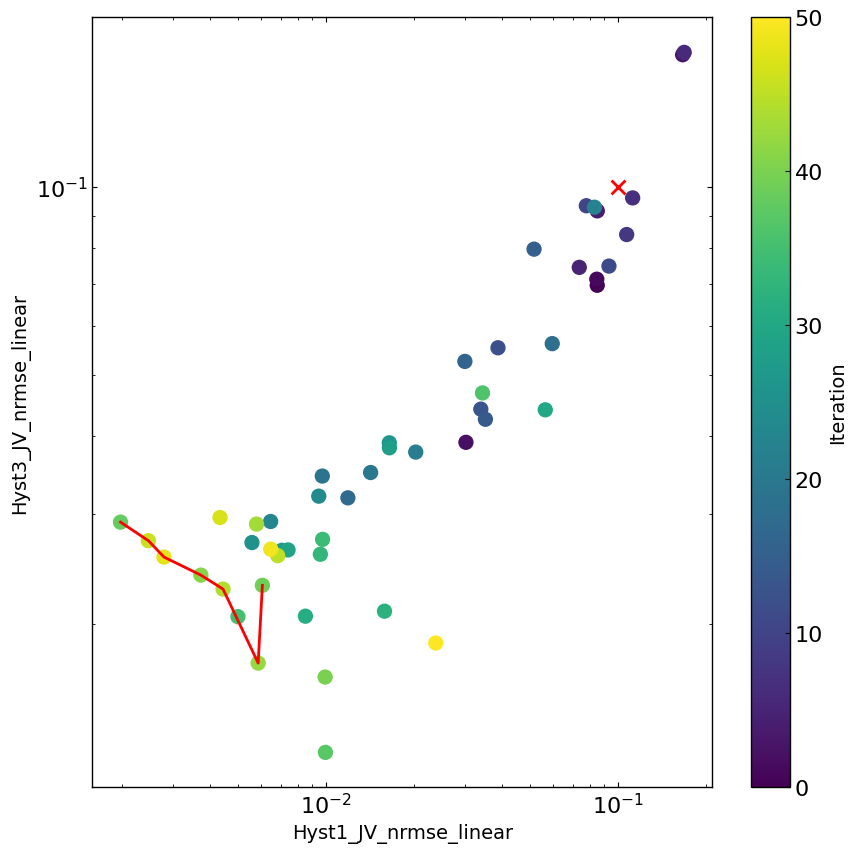

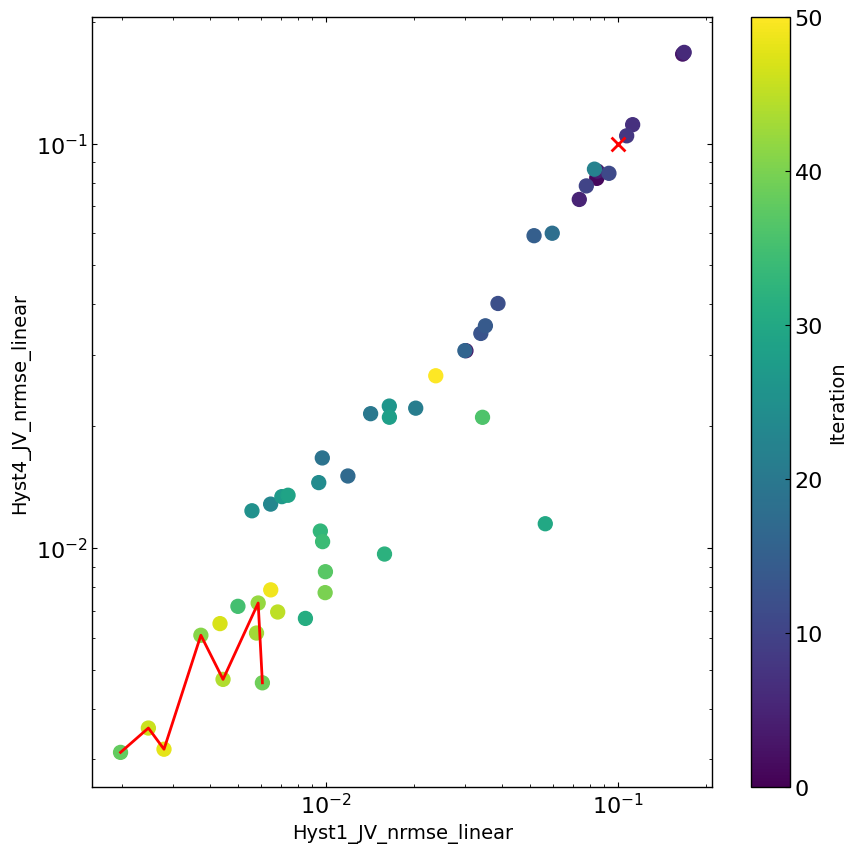

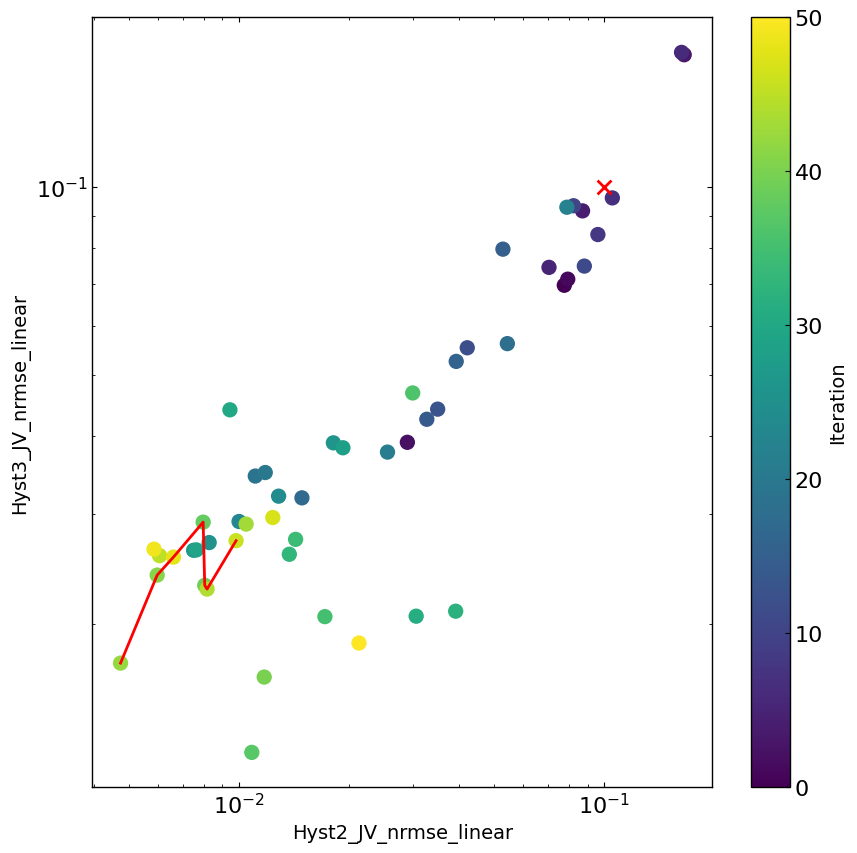

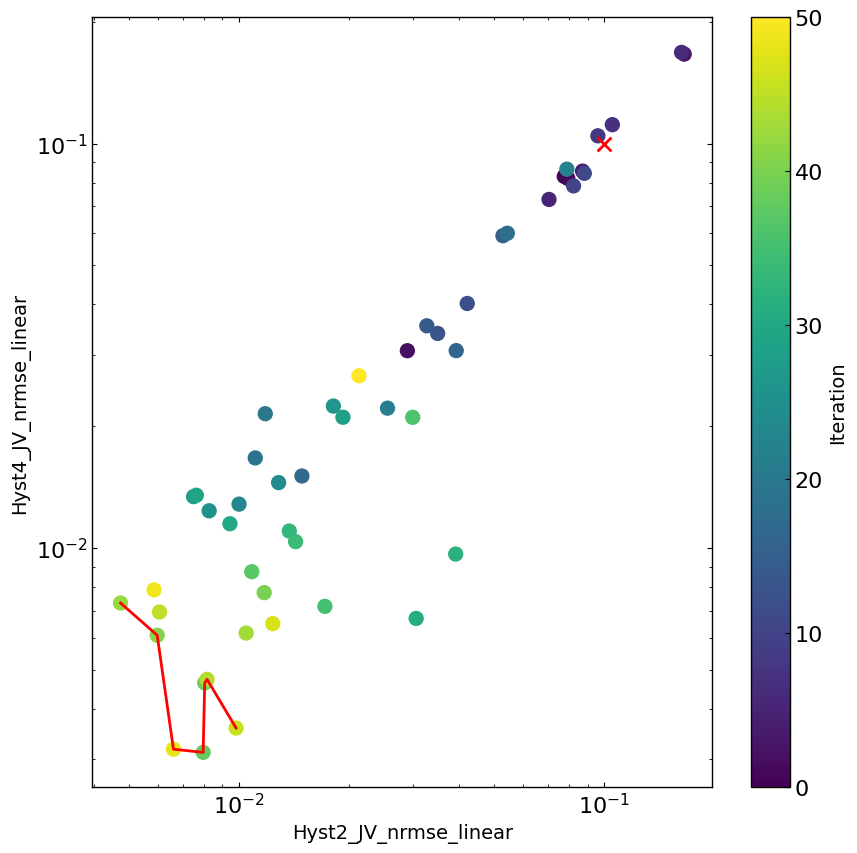

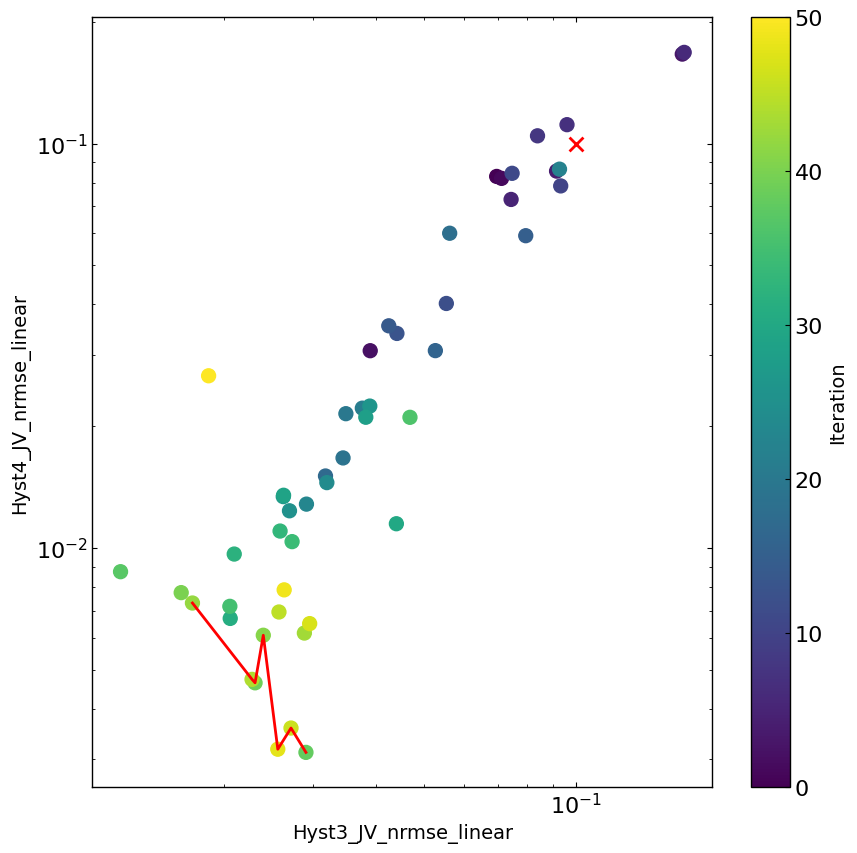

In [9]:
import matplotlib
# import itertools
from itertools import combinations
comb = list(combinations(optimizer.all_metrics, 2))
threshold_list = []
for i in range(len(optimizer.agents)):
    for j in range(len(optimizer.agents[i].threshold)):
        threshold_list.append(optimizer.agents[i].threshold[j])
threshold_comb = list(combinations(threshold_list, 2))
pareto = ax_client.get_pareto_frontier(use_model_predictions=False)
print('Pareto frontier:', pareto)
cm = matplotlib.colormaps.get_cmap('viridis')
df = get_df_from_ax(params, optimizer)
# create pareto df
dum_dic = {}
for eto in pareto:
    print(eto[1])
    for metr in optimizer.all_metrics:
        if metr not in dum_dic.keys():
            dum_dic[metr] = []
        dum_dic[metr].append(eto[1][metr][0])
df_pareto = pd.DataFrame(dum_dic)

for c,t_c in zip(comb,threshold_comb):
    plt.figure(figsize=(10, 10))
    plt.scatter(df[c[0]],df[c[1]],c=df.index, cmap=cm, marker='o', s=100) # plot the points with color according to the iteration
    cbar = plt.colorbar()
    cbar.set_label('Iteration')
    sorted_df = df_pareto.sort_values(by=c[0])
    plt.plot(sorted_df[c[0]],sorted_df[c[1]],'r') 
    plt.scatter(t_c[0],t_c[1],c='r', marker='x', s=100) # plot the threshold
    plt.xlabel(c[0])
    plt.ylabel(c[1])
    plt.xscale('log')
    plt.yscale('log')
    
    
    plt.show()


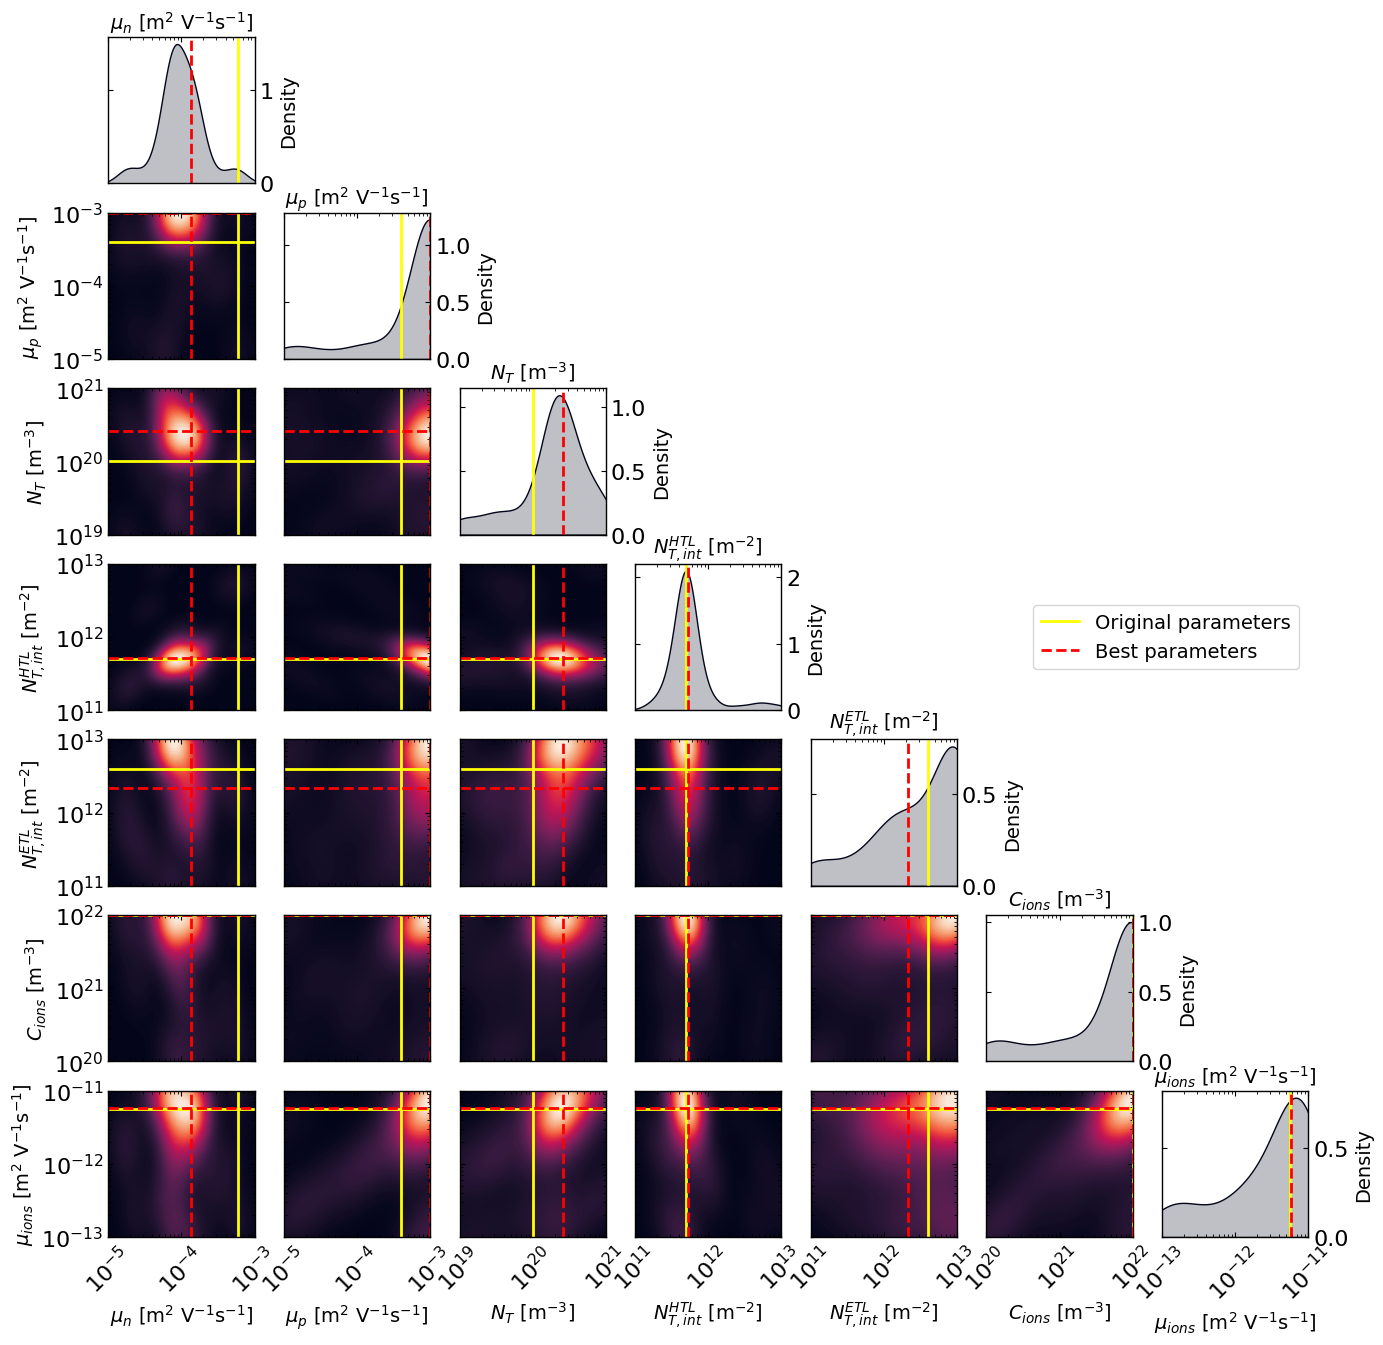

In [10]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.posterior import *
    params_orig_dict, best_parameters = {}, {}
    for p in params_orig:
        params_orig_dict[p.name] = p.value
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters, params_orig = params_orig_dict, optimizer_type = 'ax')


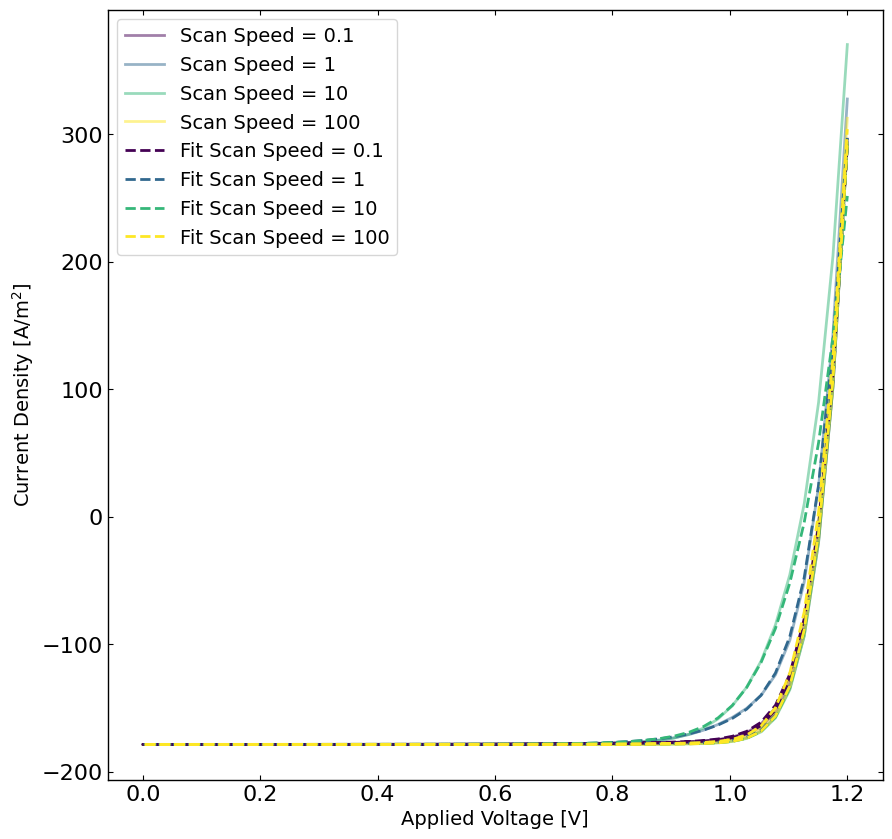

In [11]:
# rerun the simulation with the best parameters
def run_hyst(idx):
    if idx == 0:
        yfit = hyst1.run(parameters={})
        return yfit
    elif idx == 1:
        yfit = hyst2.run(parameters={})
        return yfit
    elif idx == 2:
        yfit = hyst3.run(parameters={})
        return yfit
    elif idx == 3:
        yfit = hyst4.run(parameters={})
        return yfit
# Run the simulations in parallel
results = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(run_hyst)(i) for i in range(4)
)
# Extract results hyst.run returns only yfit
yfit1 = results[0]
yfit2 = results[1]
yfit3 = results[2]
yfit4 = results[3]
# Plot the results
plt.figure(figsize=(10, 10))
viridis = plt.get_cmap('viridis', 4)
plt.plot(X1, y1, label=f'Scan Speed = 0.1',c=viridis(0),linewidth=2,alpha=0.5)
plt.plot(X2, y2, label=f'Scan Speed = 1',c=viridis(1),linewidth=2,alpha=0.5)
plt.plot(X3, y3, label=f'Scan Speed = 10',c=viridis(2),linewidth=2,alpha=0.5)
plt.plot(X4, y4, label=f'Scan Speed = 100',c=viridis(3),linewidth=2,alpha=0.5)
plt.plot(X1, yfit1, label=f'Fit Scan Speed = 0.1',c=viridis(0),linewidth=2,linestyle='--')
plt.plot(X2, yfit2, label=f'Fit Scan Speed = 1',c=viridis(1),linewidth=2,linestyle='--')
plt.plot(X3, yfit3, label=f'Fit Scan Speed = 10',c=viridis(2),linewidth=2,linestyle='--')
plt.plot(X4, yfit4, label=f'Fit Scan Speed = 100',c=viridis(3),linewidth=2,linestyle='--')
plt.xlabel('Applied Voltage [V]')
plt.ylabel('Current Density [A/m$^2$]')
plt.legend()
plt.show()



In [12]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path_zimt)
sim.delete_folders('tmp',session_path_zimt)
# uncomment the following lines to delete specific files
sim.clean_up_output('PTAA',session_path_zimt)
sim.clean_up_output('fakePerovskite',session_path_zimt)
sim.clean_up_output('C60',session_path_zimt)
sim.clean_up_output('simulation_setup_zimt_fakePerovskite',session_path_zimt)
sim.clean_up_output('freqZ',session_path_zimt)
# same for the input files
for file in optical_files:
    sim.clean_up_output(file,session_path_zimt)